Импорты


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import textwrap


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from random import sample


Загрузка датасета

In [ ]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -o Flickr8k_Dataset.zip
!unzip -o Flickr8k_text.zip


Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: __MACOSX/Flicker8k_Dataset/._3429391520_930b153f94.jpg  
  inflating: Flicker8k_Dataset/3429465163_fb8ac7ce7f.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429465163_fb8ac7ce7f.jpg  
  inflating: Flicker8k_Dataset/3429581486_4556471d1a.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429581486_4556471d1a.jpg  
  inflating: Flicker8k_Dataset/3429641260_2f035c1813.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429641260_2f035c1813.jpg  
  inflating: Flicker8k_Dataset/3429956016_3c7e3096c2.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3429956016_3c7e3096c2.jpg  
  inflating: Flicker8k_Dataset/3430100177_5864bf1e73.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3430100177_5864bf1e73.jpg  
  inflating: Flicker8k_Dataset/3430287726_94a1825bbf.jpg  
  inflating: __MACOSX/Flicker8k_Dataset/._3430287726_94a1825bbf.jpg  
  inflating: Flicker8k_Dataset/3430526230_234b3550f6.jpg  
  inflating: __MACOSX/Flicker

Загрузка и подготовка подписей

In [ ]:
def load_captions(filename):
    mapping = {}
    with open(filename, 'r') as f:
        for line in f:
            tokens = line.strip().split('\t')
            if len(tokens) != 2:
                continue
            image_id, caption = tokens
            image_id = image_id.split('#')[0]
            caption = 'startseq ' + caption.lower() + ' endseq'
            mapping.setdefault(image_id, []).append(caption)
    return mapping

captions = load_captions("Flickr8k.token.txt")

def load_set(filename):
    with open(filename) as f:
        return set(line.strip() for line in f)

train_images = load_set("Flickr_8k.trainImages.txt")
captions = {k: v for k, v in captions.items() if k in train_images}


Токенизация

In [ ]:
all_captions = [c for caps in captions.values() for c in caps]

tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=5000,
    oov_token="<unk>"
)

tokenizer.fit_on_texts(all_captions)

vocab_size = min(5000, len(tokenizer.word_index) + 1)
max_length = max(len(c.split()) for c in all_captions)

print("Vocab size:", vocab_size)
print("Max length:", max_length)


Vocab size: 5000
Max length: 40


CNN: корректный feature extractor

In [ ]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

cnn_model = Model(base_model.input, x)
cnn_model.trainable = False


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Извлечение признаков

In [ ]:
MAX_IMAGES = 2000
image_files = list(os.listdir("Flicker8k_Dataset"))[:MAX_IMAGES]

def extract_features(directory, image_list):
    features = {}
    for img_name in tqdm(image_list):
        path = os.path.join(directory, img_name)
        img = load_img(path, target_size=(299, 299))
        img = img_to_array(img)
        img = np.expand_dims(img, axis=0)
        img = preprocess_input(img)
        features[img_name] = cnn_model.predict(img, verbose=0)[0]
    return features

image_features = extract_features("Flicker8k_Dataset", image_files)
captions = {k: v for k, v in captions.items() if k in image_features}


100%|██████████| 2000/2000 [03:04<00:00, 10.86it/s]


Подготовка обучающих данных

In [ ]:
X_img, X_seq, y = [], [], []

for img, caps in captions.items():
    for cap in caps:
        seq = tokenizer.texts_to_sequences([cap])[0]
        for i in range(1, len(seq)):
            X_img.append(image_features[img])
            X_seq.append(pad_sequences([seq[:i]], maxlen=max_length)[0])
            y.append(to_categorical(seq[i], num_classes=vocab_size))

X_img = np.array(X_img)
X_seq = np.array(X_seq)
y = np.array(y)


Модель

In [ ]:
latent_dim = 512

image_input = Input(shape=(2048,))
image_dense = Dense(latent_dim, activation='relu')(image_input)

seq_input = Input(shape=(max_length,))
seq_emb = Embedding(vocab_size, latent_dim, mask_zero=True)(seq_input)

lstm_out = LSTM(latent_dim)(seq_emb, initial_state=[image_dense, image_dense])
output = Dense(vocab_size, activation='softmax')(lstm_out)

model = Model([image_input, seq_input], output)
model.compile(optimizer='adam', loss='categorical_crossentropy')
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 512)   │  2,560,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  2,099,200 │ embedding[0][0],  │
│                     │                   │            │ dense[0][0],      │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5000)      │  2,565,000 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,273,288 (31.56 MB)

 Trainable params: 8,273,288 (31.56 MB)

 Non-trainable params: 0 (0.00 B)

Обучение

In [ ]:
model.fit(
    [X_img, X_seq],
    y,
    batch_size=128,
    epochs=30,
    validation_split=0.2
)


Epoch 1/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - loss: 5.1727 - val_loss: 4.0030
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 3.7714 - val_loss: 3.7817
Epoch 3/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - loss: 3.4252 - val_loss: 3.6894
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 3.1865 - val_loss: 3.6641
Epoch 5/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.9700 - val_loss: 3.6435
Epoch 6/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.7843 - val_loss: 3.6584
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.6062 - val_loss: 3.6761
Epoch 8/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.4377 - val_loss: 3.7249
Epoch 9/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.2821 - val_loss: 3.7813
Epoch 10/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 2.1462 - val_loss: 3.8423
Epoch 11/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - loss: 2.0221 - val_loss: 3.9069
Epoch 12/30
544/544 ━━━━━━━━━━

Генерация подписей

In [ ]:
index_word = {i: w for w, i in tokenizer.word_index.items()}

def clean_caption(text):
    text = text.replace("startseq", "").replace("endseq", "").strip()
    return "\n".join(textwrap.wrap(text, 30))

def generate_caption(photo_feature):
    in_text = "startseq"
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length)
        yhat = np.argmax(model.predict([photo_feature.reshape(1,2048), seq], verbose=0))
        word = index_word.get(yhat)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    return clean_caption(in_text)


Демонстрация

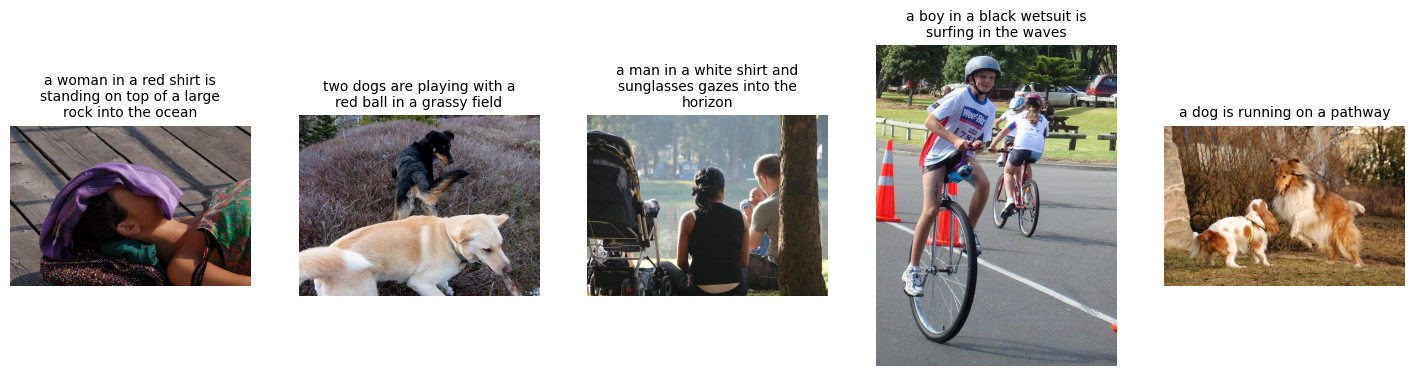

In [ ]:
num_examples = 5
samples = sample(list(image_features.keys()), num_examples)

fig, axes = plt.subplots(1, num_examples, figsize=(18, 6))

for i, img_name in enumerate(samples):
    caption = generate_caption(image_features[img_name])
    img = load_img("Flicker8k_Dataset/" + img_name)
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(caption, fontsize=10)

plt.show()


Цель работы

Разобраться в коде предыдущей команды, доработать его и обучить модель для генерации текстовых описаний изображений.

Датасет

В работе использовался датасет Flickr8k, содержащий изображения и по несколько текстовых описаний для каждого из них. Для обучения было использовано подмножество из 2000 изображений обучающей выборки, что позволило избежать переполнения оперативной памяти.

Модель

Задача решалась с помощью архитектуры CNN + LSTM:

сверточная сеть InceptionV3 (предобученная на ImageNet) использовалась для извлечения признаков изображений;

текстовые описания обрабатывались с помощью токенизации, padding и специальных токенов startseq / endseq;

генерация текста выполнялась LSTM-декодером, инициализируемым признаками изображения.

Обучение проводилось в режиме teacher forcing с использованием функции потерь categorical_crossentropy.

Результаты

После обучения модель успешно генерирует осмысленные текстовые описания изображений. Результаты были продемонстрированы на нескольких примерах, где для каждого изображения выводилась соответствующая сгенерированная подпись.

Вывод

В ходе работы был проанализирован и доработан существующий код, подобран датасет и обучена модель генерации описаний изображений. Поставленная задача выполнена, модель корректно работает и демонстрирует ожидаемое качество генерации.